Fixed 10627 predictions, saved to /Users/mac/Detect_Drill_Bit/evaluate_dataset/runs/detect/val-3/predictions_fixed.json
-- predictions_fixed --

bbox AP @ 50: 82.70

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.91     4.79     0.46     0.83     3.26     0.74  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP      13.73       2.57  



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a

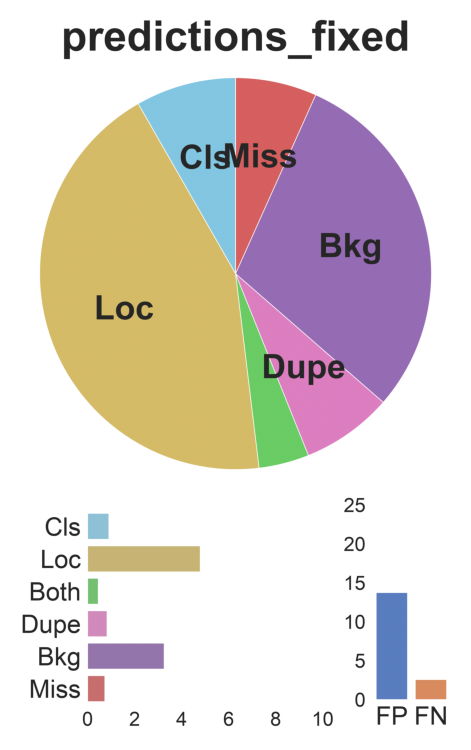

In [1]:
import json
from tidecv import TIDE, Data, datasets

def load_coco_bbox_only(json_path, name="gt"):
    with open(json_path, 'r') as f:
        coco_json = json.load(f)
    
    data = Data(name)
    
    # Build mapping filename -> image_id
    filename_to_id = {img['file_name']: img['id'] for img in coco_json.get('images', [])}
    
    # 1. Nạp danh sách các Class
    for cat in coco_json.get('categories', []):
        data.add_class(cat['id'], cat['name'])
        
    # 2. Nạp Ground Truth Annotations
    for ann in coco_json.get('annotations', []):
        image_id = ann['image_id']
        category_id = ann['category_id']
        bbox = ann['bbox'] # [x, y, width, height]
        
        if ann.get('iscrowd', 0):
            data.add_ignore_region(image_id, category_id, bbox)
        else:
            data.add_ground_truth(image_id, category_id, bbox)
            
    return data, filename_to_id

def fix_predictions_image_id(pred_json_path, filename_to_id, output_path):
    """Fix predictions.json: replace filename with numeric image_id"""
    with open(pred_json_path, 'r') as f:
        pred_data = json.load(f)
    
    fixed_preds = []
    for pred in pred_data:
        filename = pred['file_name']
        image_id = filename_to_id.get(filename)
        
        if image_id is not None:
            pred_copy = pred.copy()
            pred_copy['image_id'] = image_id
            # Remove file_name since COCO format uses image_id
            del pred_copy['file_name']
            fixed_preds.append(pred_copy)
    
    with open(output_path, 'w') as f:
        json.dump(fixed_preds, f)
    
    print(f"Fixed {len(fixed_preds)} predictions, saved to {output_path}")
    return len(fixed_preds)

# --- THỰC THI ĐÁNH GIÁ ---
tide = TIDE()

# 1. Load Ground Truth với mapping
gt, filename_to_id = load_coco_bbox_only('/Users/mac/Detect_Drill_Bit/clean-data/valid/_annotations.coco.json')

# 2. Fix predictions.json: map filename -> numeric image_id
fixed_pred_path = '/Users/mac/Detect_Drill_Bit/evaluate_dataset/runs/detect/val-3/predictions_fixed.json'
fix_predictions_image_id(
    '/Users/mac/Detect_Drill_Bit/evaluate_dataset/runs/detect/val-3/predictions.json',
    filename_to_id,
    fixed_pred_path
)

# 3. Load Predictions với COCOResult (sau khi fix)
pred = datasets.COCOResult(fixed_pred_path)

# 4. Đánh giá và in báo cáo
tide.evaluate(gt, pred, mode=TIDE.BOX)
tide.summarize()
tide.plot()